In [11]:
import evalStripped
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
evalStripped.loadPrices(evalStripped.pricesFile)

array([[100.  ,  98.49,  97.83, ...,  86.31,  87.14,  87.12],
       [116.51, 112.94, 112.7 , ...,  62.52,  62.3 ,  62.08],
       [113.55, 114.53, 112.17, ...,  86.26,  87.59,  86.62],
       ...,
       [ 66.43,  64.66,  64.19, ...,  33.17,  33.52,  34.27],
       [ 22.41,  22.1 ,  20.87, ...,   8.67,   9.  ,   9.14],
       [ 45.08,  44.28,  45.3 , ...,  17.58,  17.93,  17.83]],
      shape=(51, 500))

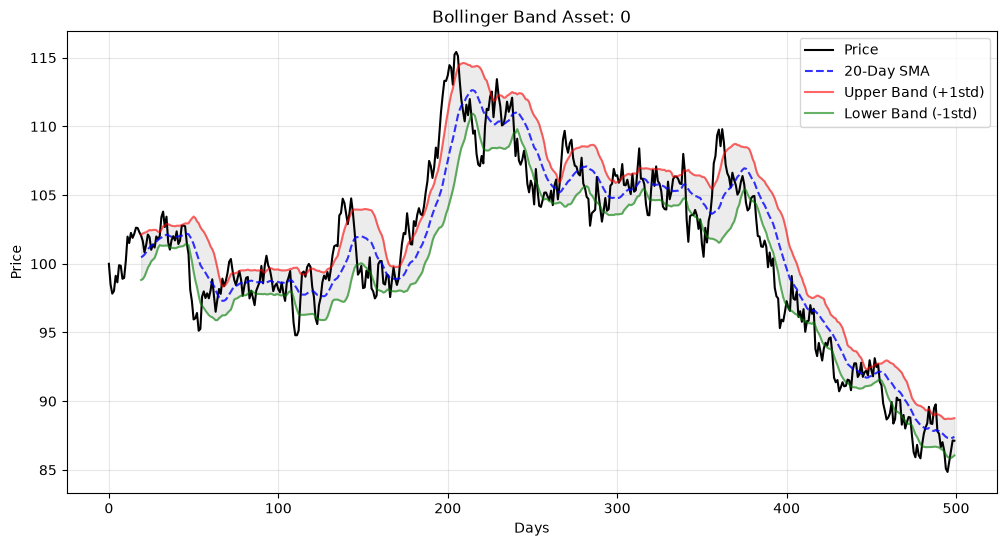

In [13]:
# get an SMA20
# get stdev

prcAll = evalStripped.prcAll

window = 20
windows = np.lib.stride_tricks.sliding_window_view(prcAll, window_shape=window, axis=1)

sma_20 = np.mean(windows, axis=-1)
# print("sma_20")
# print(sma_20)
# print(f"sma_20.shape: {sma_20.shape}")

std_20 = np.std(windows, axis=-1)

upper_band = sma_20 + std_20
lower_band = sma_20 - std_20

# sliding_window_view shrinks the 500 days to 481 days (500 - 20 + 1)
# We pad the first 19 days with NaNs so the bands align correctly with the original price array
pad_width = ((0, 0), (window - 1, 0))

sma_padded = np.pad(sma_20, pad_width, constant_values=np.nan)
upper_padded = np.pad(upper_band, pad_width, constant_values=np.nan)
lower_padded = np.pad(lower_band, pad_width, constant_values=np.nan)

asset_idx = 0  # Change this index to view different assets in your array

plt.figure(figsize=(12, 6))

# Plot the lines
plt.plot(prcAll[asset_idx], label='Price', color='black', linewidth=1.5)
plt.plot(sma_padded[asset_idx], label='20-Day SMA', color='blue', linestyle='--', alpha=0.8)
plt.plot(upper_padded[asset_idx], label='Upper Band (+1std)', color='red', alpha=0.6)
plt.plot(lower_padded[asset_idx], label='Lower Band (-1std)', color='green', alpha=0.6)

plt.fill_between(range(prcAll.shape[1]), 
                 lower_padded[asset_idx], 
                 upper_padded[asset_idx], 
                 color='gray', alpha=0.15)

plt.title(f'Bollinger Band Asset: {asset_idx}')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()